# 使用 SNN 直接训练 NinaPro 滑动窗口数据

本 Notebook 使用 40 个 sEMG 采样点作为 40 个 SNN 时间步。训练期间每个 epoch 都在测试集上评估，并按测试准确率保存 `best.pt`。因此该最佳模型属于 **test-selected checkpoint**，其结果不能视为完全无偏的最终测试估计。

In [1]:
# 设置工作目录，导入依赖包
from pathlib import Path


def find_project_root():
    """从当前目录向上查找项目根目录。"""
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "src").is_dir() and (candidate / "ninapro_data").is_dir():
            return candidate
    raise FileNotFoundError("未找到同时包含 src 和 ninapro_data 的项目根目录。")


PROJECT_ROOT = find_project_root()

# 将项目根目录加入导入路径，兼容从项目根目录或 Notebook 目录启动。
import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /root/autodl-tmp/NinaPro


## 1. 参数定义

In [ ]:
DATA_DIR = PROJECT_ROOT / "ninapro_data" / "processed" / "exerciseA" / "slide_window"

NUM_WORKERS = 8
# 训练参数
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP = 1.0
SEED = 42
DETERMINISTIC = False
MIXED_PRECISION = False

# 模型参数
INPUT_CHANNELS = 16
HIDDEN_SIZE = 256
NUM_CLASSES = 12
TAU = 2.0

# 训练结果输出目录
EXPERIMENT_NAME = f"BATCH_SIZE{BATCH_SIZE}_LR{LEARNING_RATE}_HIDDEN{HIDDEN_SIZE}_TAU{TAU}"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "raw_ninapro_snn" / EXPERIMENT_NAME

# 单批次诊断不会修改正式模型，可在确认链路正确后关闭。
RUN_OVERFIT_CHECK = False
OVERFIT_MAX_STEPS = 500
OVERFIT_TARGET_ACCURACY = 0.99
OVERFIT_SAMPLES_PER_CLASS = 2

# 仅在需要显式恢复训练时设置为 last.pt 路径。
RESUME_FROM = None

## 2. 随机种子与设备

In [3]:
from src.training import resolve_device, seed_everything

seed_everything(SEED, deterministic=DETERMINISTIC)
DEVICE = resolve_device()
print(f"DEVICE = {DEVICE}")

DEVICE = cuda


## 3. 数据

In [4]:
from src.data import create_data_pipeline

data_pipeline = create_data_pipeline(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
)
train_loader = data_pipeline.train_loader
test_loader = data_pipeline.test_loader
normalization_state = data_pipeline.normalization_state_dict()

print(f"train samples = {len(train_loader.dataset):,}")
print(f"test samples  = {len(test_loader.dataset):,}")

DataLoader 构建完成：train=140 batches, test=69 batches, num_workers=16, pin_memory=True
train samples = 17,839
test samples  = 8,787


## 4. 模型

In [5]:
from src.models.snn import NinaProSNN

model = NinaProSNN(
    input_channels=INPUT_CHANNELS,
    hidden_size=HIDDEN_SIZE,
    num_classes=NUM_CLASSES,
    tau=TAU,
)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"parameters = {parameter_count:,}")

NinaProSNN(
  input_channels=16, hidden_size=256, num_classes=12, tau=2.0, step_mode='m', backend='torch', auto_reset=True
  (input_projection): Linear(in_features=16, out_features=256, bias=True)
  (lif1): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (hidden_projection): Linear(in_features=256, out_features=256, bias=True)
  (lif2): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
  (classifier): Linear(in_features=256, out_features=12, bias=True)
)
parameters = 73,228


## 5. 单批次过拟合诊断

诊断使用正式模型的深拷贝，因此不会改变后续正式训练的初始权重。

In [6]:
import copy
import torch

from src.training import overfit_one_batch

diagnostic_history = None
if RUN_OVERFIT_CHECK:
    # 诊断训练：从每个类别中选择少量样本(2个)来确保模型能够在单批次上过拟合。
    diagnostic_indices = []
    for class_index in range(NUM_CLASSES):
        class_indices = torch.nonzero(
            train_loader.dataset.labels == class_index,
            as_tuple=False,
        ).flatten()
        diagnostic_indices.extend(class_indices[:OVERFIT_SAMPLES_PER_CLASS].tolist())
    diagnostic_samples = [train_loader.dataset[index] for index in diagnostic_indices]
    diagnostic_batch = (
        torch.stack([sample[0] for sample in diagnostic_samples]),
        torch.stack([sample[1] for sample in diagnostic_samples]),
    )
    diagnostic_model = copy.deepcopy(model)
    diagnostic_history = overfit_one_batch(
        diagnostic_model,
        diagnostic_batch,
        max_steps=OVERFIT_MAX_STEPS,
        target_accuracy=OVERFIT_TARGET_ACCURACY,
        learning_rate=LEARNING_RATE,
        gradient_clip=GRADIENT_CLIP,
        device=DEVICE,
    )
    final_diagnostic = diagnostic_history[-1]
    print(
        f"diagnostic steps={len(diagnostic_history)}, "
        f"loss={final_diagnostic['loss']:.4f}, "
        f"accuracy={final_diagnostic['accuracy'] * 100:.2f}%"
    )

## 6. 正式训练

该单元会运行完整训练，并在 `outputs/raw_ninapro_snn` 下保存 history、指标、图像以及 last/best/final 三类检查点。

In [ ]:
from src.training import fit

experiment_config = {
    "seed": SEED,
    "deterministic": DETERMINISTIC,
    "data_dir": str(DATA_DIR),
    "model": {
        "name": "NinaProSNN",
        "input_channels": INPUT_CHANNELS,
        "hidden_size": HIDDEN_SIZE,
        "num_classes": NUM_CLASSES,
        "tau": TAU,
    },
}

history = fit(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    output_dir=OUTPUT_DIR,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    gradient_clip=GRADIENT_CLIP,
    device=DEVICE,
    mixed_precision=MIXED_PRECISION,
    normalization_state=normalization_state,
    config=experiment_config,
    resume_from=RESUME_FROM,
)

device=cuda, amp=False, epochs=1..100


Train 001/100:   0%|          | 0/140 [00:00<?, ?it/s]

Test  001/100:   0%|          | 0/69 [00:00<?, ?it/s]

epoch 001/100 | train loss 1.9266, acc 32.60% | test loss 1.6098, acc 43.12% | lr 1.000e-02 | 9.25s *


Train 002/100:   0%|          | 0/140 [00:00<?, ?it/s]

...

epoch 076/100 | train loss 0.0440, acc 99.70% | test loss 1.7830, acc 59.74% | lr 1.464e-03 | 6.87s


Train 077/100:   0%|          | 0/140 [00:00<?, ?it/s]

Test  077/100:   0%|          | 0/69 [00:00<?, ?it/s]

epoch 077/100 | train loss 0.0432, acc 99.74% | test loss 1.7728, acc 59.82% | lr 1.355e-03 | 6.37s


Train 078/100:   0%|          | 0/140 [00:00<?, ?it/s]

## 7. 最佳模型结果

best epoch       = 36
test accuracy    = 56.88%
macro precision  = 57.73%
macro recall     = 57.25%
macro F1         = 57.18%
注意：以上结果来自 test-selected checkpoint。


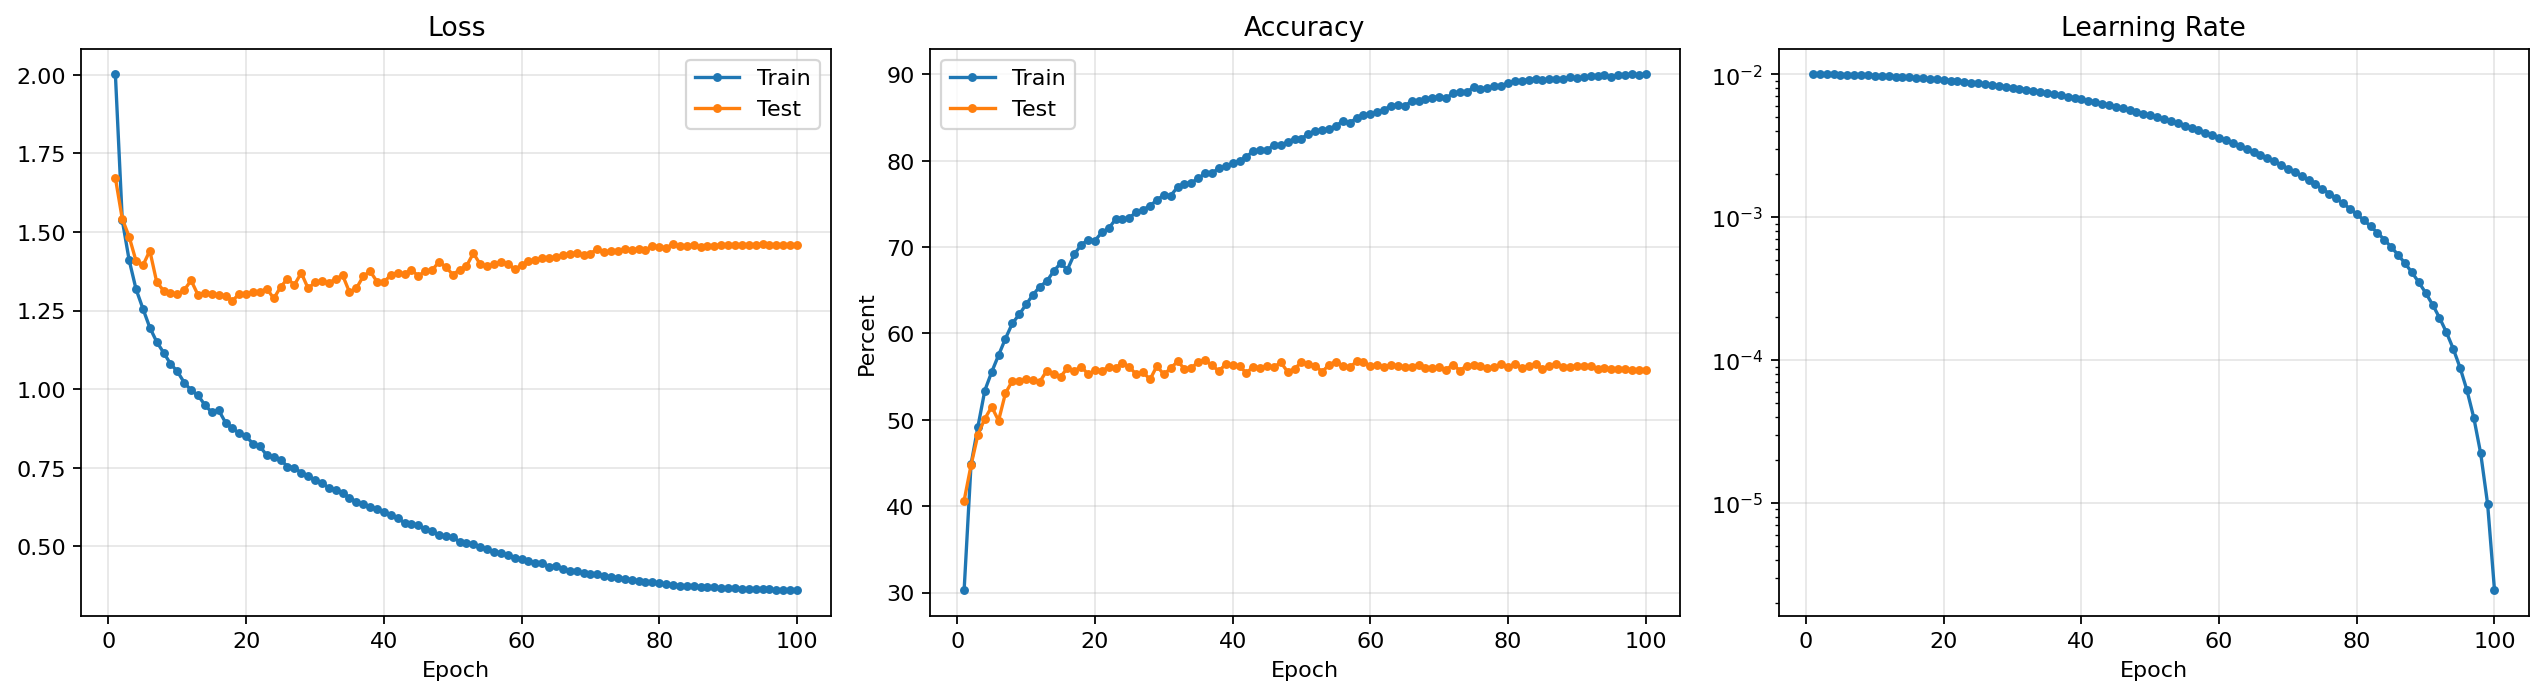

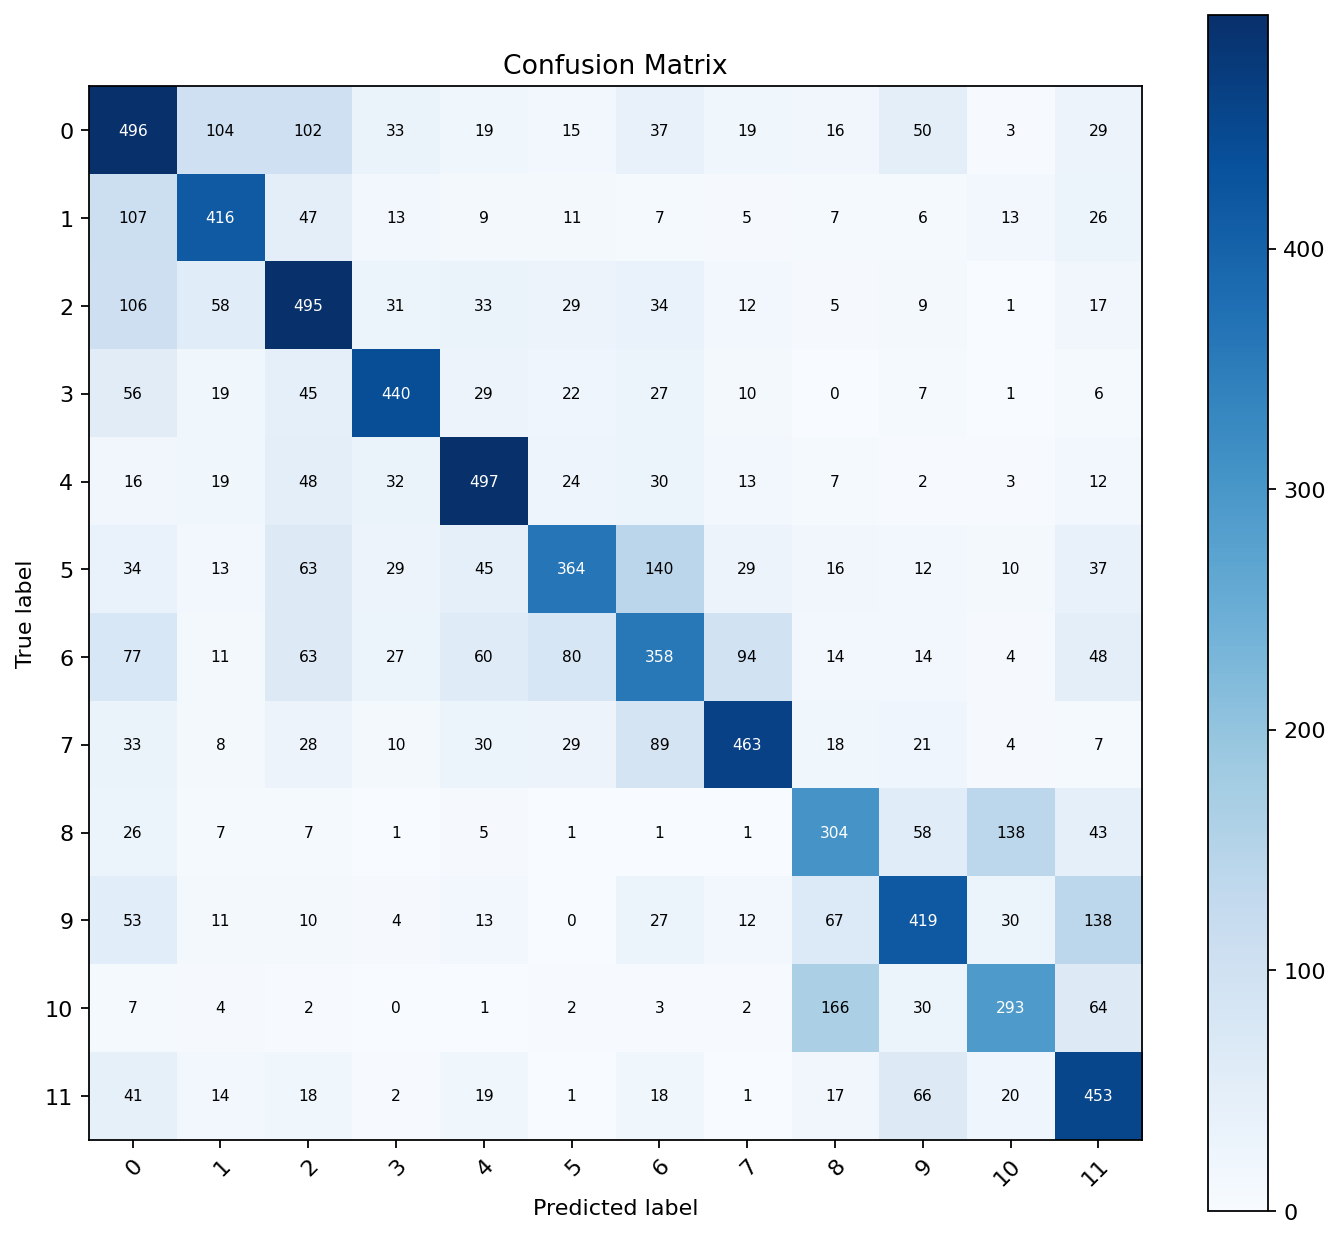

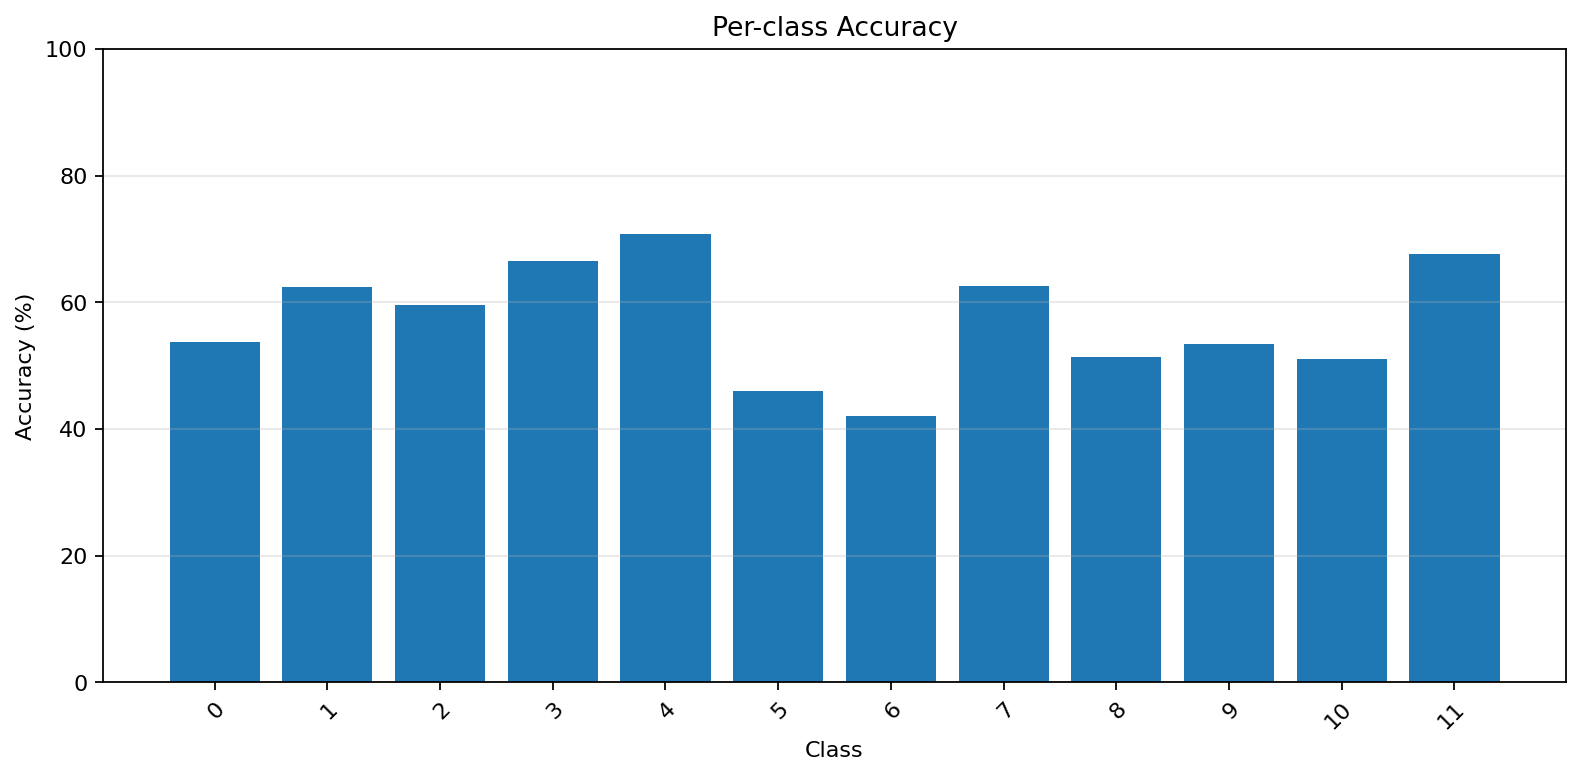

In [ ]:
import json
from IPython.display import Image, display

metrics_path = OUTPUT_DIR / "metrics.json"
best_metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
print(f"best epoch       = {best_metrics['best_epoch']}")
print(f"test accuracy    = {best_metrics['accuracy'] * 100:.2f}%")
print(f"macro precision  = {best_metrics['macro_precision'] * 100:.2f}%")
print(f"macro recall     = {best_metrics['macro_recall'] * 100:.2f}%")
print(f"macro F1         = {best_metrics['macro_f1'] * 100:.2f}%")
print("注意：以上结果来自 test-selected checkpoint。")

for filename in ("training_curves.png", "confusion_matrix.png", "per_class_accuracy.png"):
    display(Image(filename=str(OUTPUT_DIR / "figures" / filename)))